In [1]:
pip install seaborn

Note: you may need to restart the kernel to use updated packages.


In [2]:
pip install scikit-learn

Note: you may need to restart the kernel to use updated packages.


In [3]:
pip install LinearRegression 

Note: you may need to restart the kernel to use updated packages.


In [4]:
pip install statsmodels

Note: you may need to restart the kernel to use updated packages.


In [5]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import sklearn.linear_model 
import LinearRegression
import sklearn.metrics 
from sklearn.metrics import r2_score, mean_squared_error
from statsmodels.tsa.seasonal import seasonal_decompose
from statsmodels.tsa.seasonal import seasonal_decompose
import statsmodels.tsa.stattools 
from statsmodels.tsa.stattools import coint
import warnings
import datetime
warnings.filterwarnings('ignore')


In [6]:
df = pd.read_csv('marketing_AB.csv') 

In [7]:
df.head()

,Unnamed: 0,user id,test group,converted,total ads,most ads day,most ads hour
0,0,1069124,ad,False,130,Monday,20
1,1,1119715,ad,False,93,Tuesday,22
2,2,1144181,ad,False,21,Tuesday,18
3,3,1435133,ad,False,355,Tuesday,10
4,4,1015700,ad,False,276,Friday,14


In [8]:
df.shape

(588101, 7)

In [9]:
df.dtypes

Unnamed: 0        int64
user id           int64
test group       object
converted          bool
total ads         int64
most ads day     object
most ads hour     int64
dtype: object

In [11]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 588101 entries, 0 to 588100
Data columns (total 7 columns):
 #   Column         Non-Null Count   Dtype 
---  ------         --------------   ----- 
 0   Unnamed: 0     588101 non-null  int64 
 1   user id        588101 non-null  int64 
 2   test group     588101 non-null  object
 3   converted      588101 non-null  bool  
 4   total ads      588101 non-null  int64 
 5   most ads day   588101 non-null  object
 6   most ads hour  588101 non-null  int64 
dtypes: bool(1), int64(4), object(2)
memory usage: 27.5+ MB


In [12]:
df.describe()

,Unnamed: 0,user id,total ads,most ads hour
count,588101.000000,5.881010e+05,588101.000000,588101.000000
mean,294050.000000,1.310692e+06,24.820876,14.469061
std,169770.279668,2.022260e+05,43.715181,4.834634
min,0.000000,9.000000e+05,1.000000,0.000000
25%,147025.000000,1.143190e+06,4.000000,11.000000
50%,294050.000000,1.313725e+06,13.000000,14.000000
75%,441075.000000,1.484088e+06,27.000000,18.000000
max,588100.000000,1.654483e+06,2065.000000,23.000000


In [13]:
df.isnull().sum()

Unnamed: 0       0
user id          0
test group       0
converted        0
total ads        0
most ads day     0
most ads hour    0
dtype: int64

In [ ]:
# PHASE - 1:- Data Cleaning and Understanding --->

In [15]:
# Remove the unnecessary column
df.drop("Unnamed: 0", axis=1, inplace=True)

In [16]:
df.head()

,user id,test group,converted,total ads,most ads day,most ads hour
0,1069124,ad,False,130,Monday,20
1,1119715,ad,False,93,Tuesday,22
2,1144181,ad,False,21,Tuesday,18
3,1435133,ad,False,355,Tuesday,10
4,1015700,ad,False,276,Friday,14


In [17]:
#  Rename the columns
df.columns = [
    "user_id",
    "test_group",
    "converted",
    "total_ads",
    "most_ads_day",
    "most_ads_hour"
]

In [19]:
df.columns

Index(['user_id', 'test_group', 'converted', 'total_ads', 'most_ads_day',
       'most_ads_hour'],
      dtype='object')

In [21]:
# Check for duplicate users
df["user_id"].duplicated().sum()

np.int64(0)

In [22]:
df = df.drop_duplicates(subset="user_id")

In [23]:
df["user_id"].duplicated().sum()

np.int64(0)

In [24]:
# Check A/B group sizes
df["test_group"].value_counts()

test_group
ad     564577
psa     23524
Name: count, dtype: int64

In [25]:
# Check conversion rates
df.groupby("test_group")["converted"].mean()

test_group
ad     0.025547
psa    0.017854
Name: converted, dtype: float64

In [26]:
#  PHASE - 2:- Exploratory Data Analysis (EDA)

In [27]:
#  Overall conversion rate 
df["converted"].mean()

np.float64(0.02523886203220195)

In [28]:
(df["converted"].mean())*100

np.float64(2.523886203220195)

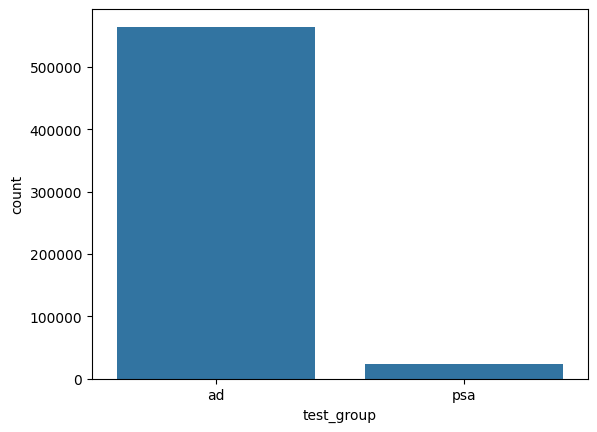

In [30]:
#  Visualize A/B Groups 
import seaborn as sns 
import matplotlib.pyplot as plt

sns.countplot(data=df, x="test_group")
plt.show()

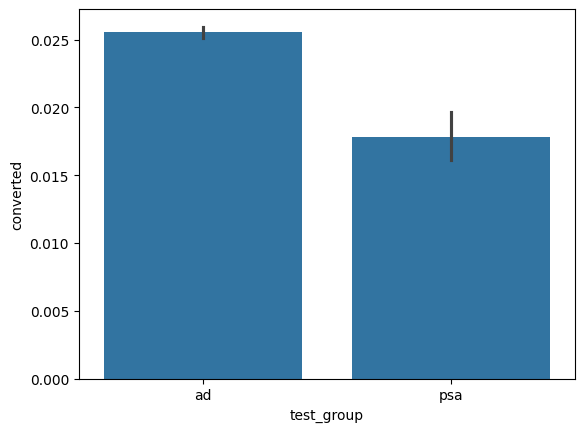

In [32]:
#  Conversion by Group

sns.barplot(
    data=df,
    x="test_group",
    y="converted"
)
plt.show()

#  Question--> Which group converts better?

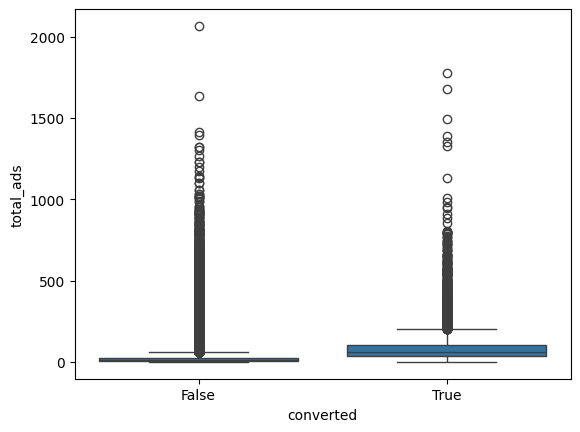

In [33]:
#  Ads exposure Analysis

sns.boxplot(
    data=df,
    x="converted",
    y="total_ads"
)
plt.show()

#  Question ---> Do converters generally see more ads?

In [34]:
#  Day analysis 
df.groupby("most_ads_day")["converted"].mean().sort_values(ascending=False)

most_ads_day
Monday       0.032812
Tuesday      0.029840
Wednesday    0.024942
Sunday       0.024476
Friday       0.022212
Thursday     0.021571
Saturday     0.021051
Name: converted, dtype: float64

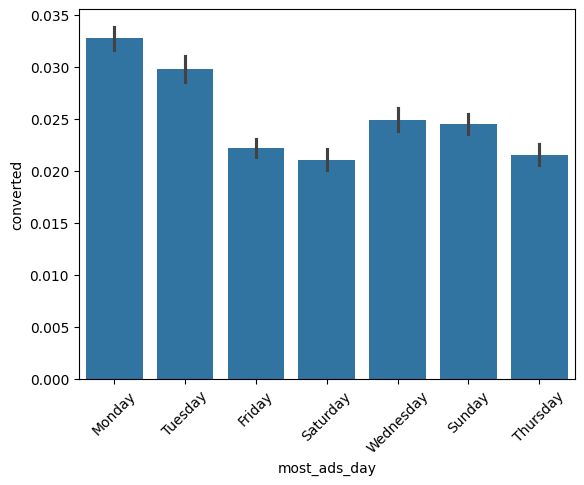

In [35]:
sns.barplot(
    data=df,
    x="most_ads_day",
    y="converted"
)
plt.xticks(rotation=45)
plt.show()

In [37]:
# Hour Analysis

df.groupby("most_ads_hour")["converted"].mean()

most_ads_hour
0     0.018425
1     0.012911
2     0.007313
3     0.010452
4     0.015235
5     0.020915
6     0.022244
7     0.018111
8     0.019516
9     0.019191
10    0.021521
11    0.022116
12    0.023828
13    0.024677
14    0.028063
15    0.029653
16    0.030772
17    0.028210
18    0.027380
19    0.026720
20    0.029803
21    0.028923
22    0.026105
23    0.022662
Name: converted, dtype: float64

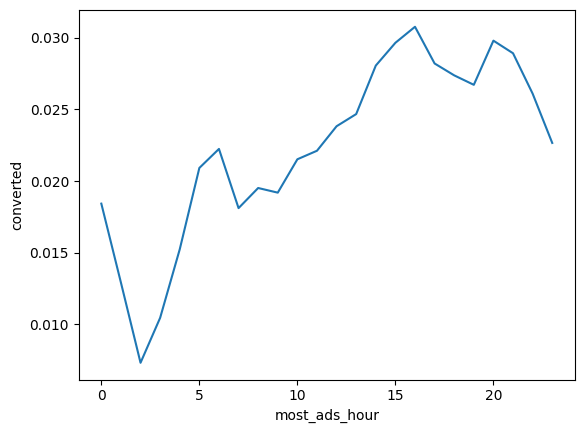

In [38]:
sns.lineplot(
    data=df.groupby("most_ads_hour")["converted"].mean().reset_index(),
    x="most_ads_hour",
    y="converted"
)
plt.show()

# Question --->  At which hour are users most likely to convert?

In [39]:
# PHASE 3: A/B Testing (Most Important Part)

In [40]:
#  Create Groups 
ad_group = df[df["test_group"]=="ad"]["converted"]
psa_group = df[df["test_group"]=="psa"]["converted"]

In [41]:
#  Perform Hypothesis Test
# Using a z-test for proportions

from statsmodels.stats.proportion import proportions_ztest

In [43]:
# Calculating

success = [
    ad_group.sum(),
    psa_group.sum()
]

nobs = [
    len(ad_group),
    len(psa_group),
]

z_stat, p_value = proportions_ztest(
    success,
    nobs
)

print(z_stat)
print(p_value)

7.3700781265454145
1.7052807161559727e-13


In [44]:
#  PHASE 4:  REGRESSION ANALYSIS

In [45]:
# Convert Categorical Variables

df_reg = pd.get_dummies(
    df,
    columns=["test_group","most_ads_day"],
    drop_first=True
)

In [46]:
# Convert Boolean Target

df_reg["converted"] = df_reg["converted"].astype(int)

In [48]:
# Define features 

X = df_reg.drop(
    ["user_id", "converted"],
    axis=1
)

y = df_reg["converted"]

In [50]:
#  Train/Test Split

from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

In [51]:
# Logistic Regression

from sklearn.linear_model import LogisticRegression

model = LogisticRegression(max_iter=1000)

model.fit(X_train, y_train)

,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add a L2 penalty term and it is the default choice;- `'l1'`: add a L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'` and `l1_ratio` set to any float between 0 and 1 for `'penalty='elasticnet'`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation `) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary ` for details.",None
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lbfgs'.To choose a solver, you might want to consider the following aspects:- 'lbfgs' is a good default solver because it works reasonably well for a wide class of problems.- For :term:`mul

In [53]:
#  Evaluate

from sklearn.metrics import accuracy_score

pred = model.predict(X_test)

accuracy_score(y_test,pred)

0.9734656226354137

In [54]:
# Feature importance

pd.DataFrame({
    "feature": X.columns,
    "Coefficient":model.coef_[0]
}).sort_values(
    "Coefficient",
    ascending=False
)

,feature,Coefficient
3,most_ads_day_Monday,0.455608
7,most_ads_day_Tuesday,0.417665
5,most_ads_day_Sunday,0.204540
8,most_ads_day_Wednesday,0.186845
6,most_ads_day_Thursday,0.034297
1,most_ads_hour,0.033352
0,total_ads,0.010273
4,most_ads_day_Saturday,0.001164
2,test_group_psa,-0.429644


In [58]:
#  Connecting to Postgresql

import pandas as pd
from sqlalchemy import create_engine
username = "postgres"
password = "123456789"
host = "localhost"
port = "5432"
database = "marketing_analysis"

engine = create_engine(
    f"postgresql+psycopg://{username}:{password}@{host}:{port}/{database}"
)

In [59]:
df.to_sql(
    "marketing_ab_test",
    con=engine,
    if_exists="replace",
    index=False
)
print("Table uploaded successfully!")

Table uploaded successfully!
